In [1]:
import os
import time
import copy
import torch
import shutil
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn, optim
import torch.nn.functional as F
from model_utils import (
    combine_datasets,
    split_dataset,
    count_images_in_directory,
    copy_images
)

In [6]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


original_dataset_dir = '/workspace/archive/Lumpy Skin Images Dataset'
combined_dataset_dir = '/workspace/archive/combined_dataset'


original_normal_skin_dir = os.path.join(original_dataset_dir, 'Normal Skin')
original_lumpy_skin_dir = os.path.join(original_dataset_dir, 'Lumpy Skin')


combined_normal_skin_dir = os.path.join(combined_dataset_dir, 'Normal Skin')
combined_lumpy_skin_dir = os.path.join(combined_dataset_dir, 'Lumpy Skin')

original_train_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=train_transforms)
original_valid_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=valid_transforms)
combined_train_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=train_transforms)
combined_valid_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=valid_transforms)


original_train_loader = DataLoader(original_train_dataset, batch_size=32, shuffle=True)
original_valid_loader = DataLoader(original_valid_dataset, batch_size=32, shuffle=False)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True)
combined_valid_loader = DataLoader(combined_valid_dataset, batch_size=32, shuffle=False)

original_test_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=valid_transforms)
combined_test_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=valid_transforms)


original_test_loader = DataLoader(original_test_dataset, batch_size=32, shuffle=False)
combined_test_loader = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)


print("Original Dataset (Training):")
print(f"Number of batches: {len(original_train_loader)}")
for images, labels in original_train_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nCombined Dataset (Training):")
print(f"Number of batches: {len(combined_train_loader)}")
for images, labels in combined_train_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nOriginal Dataset (Validation):")
print(f"Number of batches: {len(original_valid_loader)}")
for images, labels in original_valid_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nCombined Dataset (Validation):")
print(f"Number of batches: {len(combined_valid_loader)}")
for images, labels in combined_valid_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nOriginal Dataset (Test):")
print(f"Number of batches: {len(original_test_loader)}")
for images, labels in original_test_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nCombined Dataset (Test):")
print(f"Number of batches: {len(combined_test_loader)}")
for images, labels in combined_test_loader:
    print(f"Image batch size: {images.size()}")
    break


Original Dataset (Training):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Training):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])

Original Dataset (Validation):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Validation):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])

Original Dataset (Test):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Test):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])


In [7]:

class CustomResNet50Model(nn.Module):
    def __init__(self):
        super(CustomResNet50Model, self).__init__()
        

        self.base_model = models.resnet50(pretrained=True) 
        
        self.base_model.fc = nn.Identity() 

        for param in self.base_model.parameters():
            param.requires_grad = False
        
        self.fc1 = nn.Linear(2048, 1024)  
        self.dropout = nn.Dropout(0.15)  
        self.fc2 = nn.Linear(1024, 2)  
        
    def forward(self, x):
        
        x = self.base_model(x)
        x = self.fc1(x)
        x = torch.relu(x)  
        x = self.dropout(x)
        x = self.fc2(x)  
        return x


In [8]:
custom_model = CustomResNet50Model()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
custom_model.to(device)
print (custom_model)


CustomResNet50Model(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequent

In [9]:
learning_rate = 1e-4  
batch_size = 32

optimizer = optim.Adam(custom_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

original_train_loss_history = []
original_train_accuracy_history = []
original_valid_loss_history = []
original_valid_accuracy_history = []

combined_train_loss_history = []
combined_train_accuracy_history = []
combined_valid_loss_history = []
combined_valid_accuracy_history = []


model_dir = "./models4"
os.makedirs(model_dir, exist_ok=True)

def train_phase(train_loader, model, optimizer, criterion, dataset_name="Train"):
    model.train()  
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_predictions = 0

    for inputs, labels in train_loader:
       
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
    
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)  
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == labels).sum().item()
        total_train_predictions += labels.size(0)

    train_acc = correct_train_predictions / total_train_predictions
    train_loss = running_train_loss / len(train_loader.dataset)
    
    if dataset_name == "Original":
        original_train_loss_history.append(train_loss)
        original_train_accuracy_history.append(train_acc)
    else:
        combined_train_loss_history.append(train_loss)
        combined_train_accuracy_history.append(train_acc)
    
    print(f"{dataset_name} Phase: Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    
    return train_loss, train_acc


def validation_phase(valid_loader, model, criterion, dataset_name="Validation"):
    model.eval()  
    running_valid_loss = 0.0
    correct_valid_predictions = 0
    total_valid_predictions = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            running_valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_valid_predictions += (predicted == labels).sum().item()
            total_valid_predictions += labels.size(0)

    valid_acc = correct_valid_predictions / total_valid_predictions
    valid_loss = running_valid_loss / len(valid_loader.dataset)
    
    if dataset_name == "Original":
        original_valid_loss_history.append(valid_loss)
        original_valid_accuracy_history.append(valid_acc)
    else:
        combined_valid_loss_history.append(valid_loss)
        combined_valid_accuracy_history.append(valid_acc)
    
    print(f"{dataset_name} Phase: Loss: {valid_loss:.4f}, Accuracy: {valid_acc:.4f}")
    
    return valid_loss, valid_acc


def train_model(train_loader, valid_loader, model, optimizer, criterion, epochs=30, patience=5, dataset_name="Original"):
    """
    Main training loop for training the model.
    """
    best_model_wts = copy.deepcopy(model.state_dict())  
    best_val_acc = 0.0
    early_stop_counter = 0


    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs} - Dataset: {dataset_name}")

        start_time = time.time()


        train_loss, train_acc = train_phase(train_loader, model, optimizer, criterion, dataset_name)

        valid_loss, valid_acc = validation_phase(valid_loader, model, criterion, dataset_name)

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_acc:.4f}")

        if valid_acc > best_val_acc:
            print(f"Validation accuracy improved from {best_val_acc:.4f} to {valid_acc:.4f}. Saving model.")
            best_val_acc = valid_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            model_path = os.path.join(model_dir, f"{dataset_name}_model_{epoch + 1:02d}-{valid_acc:.4f}.pth")
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0  
        else:
            print(f"Validation accuracy did not improve from {best_val_acc:.4f}")
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch + 1} completed in {epoch_time:.2f} seconds.")

    
    model.load_state_dict(best_model_wts)

    return model, best_val_acc


In [10]:
custom_model, best_val_acc_original = train_model(
    original_train_loader, 
    original_valid_loader, 
    custom_model, 
    optimizer, 
    criterion, 
    dataset_name="Original"
)



Epoch 1/30 - Dataset: Original
Original Phase: Loss: 0.5079, Accuracy: 0.7482
Original Phase: Loss: 0.3633, Accuracy: 0.8943
Train Loss: 0.5079, Train Accuracy: 0.7482
Validation Loss: 0.3633, Validation Accuracy: 0.8943
Validation accuracy improved from 0.0000 to 0.8943. Saving model.
Epoch 1 completed in 15.61 seconds.

Epoch 2/30 - Dataset: Original
Original Phase: Loss: 0.3387, Accuracy: 0.8768
Original Phase: Loss: 0.3938, Accuracy: 0.8107
Train Loss: 0.3387, Train Accuracy: 0.8768
Validation Loss: 0.3938, Validation Accuracy: 0.8107
Validation accuracy did not improve from 0.8943
Epoch 2 completed in 6.87 seconds.

Epoch 3/30 - Dataset: Original
Original Phase: Loss: 0.2952, Accuracy: 0.8925
Original Phase: Loss: 0.2788, Accuracy: 0.8888
Train Loss: 0.2952, Train Accuracy: 0.8925
Validation Loss: 0.2788, Validation Accuracy: 0.8888
Validation accuracy did not improve from 0.8943
Epoch 3 completed in 7.73 seconds.

Epoch 4/30 - Dataset: Original
Original Phase: Loss: 0.2981, Accu

In [11]:
custom_model_combined, best_val_acc_combined = train_model(
    combined_train_loader, 
    combined_valid_loader, 
    custom_model, 
    optimizer, 
    criterion, 
    dataset_name="Combined"
)



Epoch 1/30 - Dataset: Combined
Combined Phase: Loss: 0.3022, Accuracy: 0.8768
Combined Phase: Loss: 0.2601, Accuracy: 0.8914
Train Loss: 0.3022, Train Accuracy: 0.8768
Validation Loss: 0.2601, Validation Accuracy: 0.8914
Validation accuracy improved from 0.0000 to 0.8914. Saving model.
Epoch 1 completed in 18.47 seconds.

Epoch 2/30 - Dataset: Combined
Combined Phase: Loss: 0.3251, Accuracy: 0.8585
Combined Phase: Loss: 0.3165, Accuracy: 0.8643
Train Loss: 0.3251, Train Accuracy: 0.8585
Validation Loss: 0.3165, Validation Accuracy: 0.8643
Validation accuracy did not improve from 0.8914
Epoch 2 completed in 17.62 seconds.

Epoch 3/30 - Dataset: Combined
Combined Phase: Loss: 0.2728, Accuracy: 0.8901
Combined Phase: Loss: 0.2075, Accuracy: 0.9218
Train Loss: 0.2728, Train Accuracy: 0.8901
Validation Loss: 0.2075, Validation Accuracy: 0.9218
Validation accuracy improved from 0.8914 to 0.9218. Saving model.
Epoch 3 completed in 18.31 seconds.

Epoch 4/30 - Dataset: Combined
Combined Phase

In [12]:
# Training phase on Original Dataset
train_loss_original, train_accuracy_original = train_phase(
    train_loader=original_train_loader, 
    model=custom_model, 
    optimizer=optimizer, 
    criterion=criterion, 
    dataset_name="Original"
)

# Validation phase on Original Dataset
valid_loss_original, valid_accuracy_original = validation_phase(
    valid_loader=original_valid_loader, 
    model=custom_model, 
    criterion=criterion, 
    dataset_name="Original"
)

# Training phase on Combined Dataset
train_loss_combined, train_accuracy_combined = train_phase(
    train_loader=combined_train_loader, 
    model=custom_model, 
    optimizer=optimizer, 
    criterion=criterion, 
    dataset_name="Combined"
)

# Validation phase on Combined Dataset
valid_loss_combined, valid_accuracy_combined = validation_phase(
    valid_loader=combined_valid_loader, 
    model=custom_model, 
    criterion=criterion, 
    dataset_name="Combined"
)

# Test phase for Original Dataset
test_loss_original, test_acc_original = validation_phase(
    valid_loader=original_test_loader,
    model=custom_model,
    criterion=criterion,
    dataset_name="Original Test"
)

# Test phase for Combined Dataset
test_loss_combined, test_acc_combined = validation_phase(
    valid_loader=combined_test_loader,
    model=custom_model,
    criterion=criterion,
    dataset_name="Combined Test"
)

# Print the results
print(f"--- Original Dataset ---")
print(f"Training Loss: {train_loss_original:.4f}, Training Accuracy: {train_accuracy_original:.4f}")
print(f"Validation Loss: {valid_loss_original:.4f}, Validation Accuracy: {valid_accuracy_original:.4f}")
print(f"Test Loss: {test_loss_original:.4f}, Test Accuracy: {test_acc_original:.4f}")

print(f"\n--- Combined Dataset ---")
print(f"Training Loss: {train_loss_combined:.4f}, Training Accuracy: {train_accuracy_combined:.4f}")
print(f"Validation Loss: {valid_loss_combined:.4f}, Validation Accuracy: {valid_accuracy_combined:.4f}")
print(f"Test Loss: {test_loss_combined:.4f}, Test Accuracy: {test_acc_combined:.4f}")


Original Phase: Loss: 0.2549, Accuracy: 0.8980
Original Phase: Loss: 0.2926, Accuracy: 0.8842
Combined Phase: Loss: 0.2450, Accuracy: 0.9035
Combined Phase: Loss: 0.2115, Accuracy: 0.9201
Original Test Phase: Loss: 0.2718, Accuracy: 0.8906
Combined Test Phase: Loss: 0.2115, Accuracy: 0.9201
--- Original Dataset ---
Training Loss: 0.2549, Training Accuracy: 0.8980
Validation Loss: 0.2926, Validation Accuracy: 0.8842
Test Loss: 0.2718, Test Accuracy: 0.8906

--- Combined Dataset ---
Training Loss: 0.2450, Training Accuracy: 0.9035
Validation Loss: 0.2115, Validation Accuracy: 0.9201
Test Loss: 0.2115, Test Accuracy: 0.9201


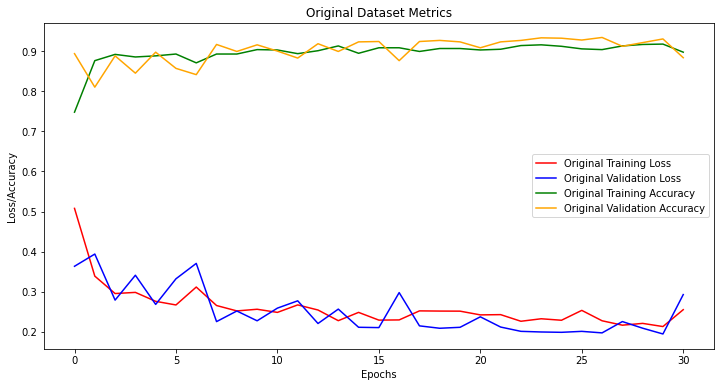

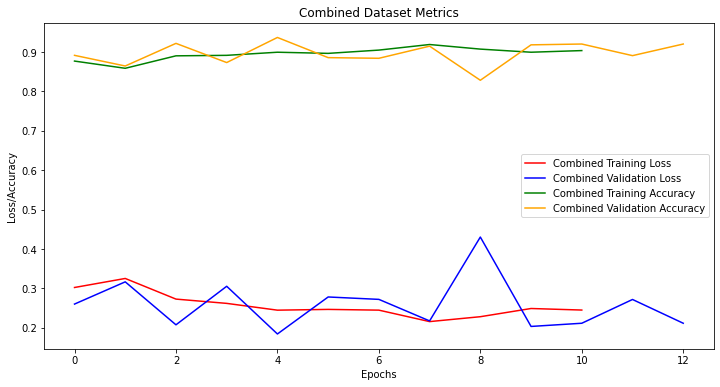

In [13]:
# Plot for original dataset
plt.figure(figsize=(12, 6))
plt.plot(original_train_loss_history, label="Original Training Loss", color='red')
plt.plot(original_valid_loss_history, label="Original Validation Loss", color='blue')
plt.plot(original_train_accuracy_history, label="Original Training Accuracy", color='green')
plt.plot(original_valid_accuracy_history, label="Original Validation Accuracy", color='orange')
plt.title("Original Dataset Metrics")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

# Plot for combined dataset
plt.figure(figsize=(12, 6))
plt.plot(combined_train_loss_history, label="Combined Training Loss", color='red')
plt.plot(combined_valid_loss_history, label="Combined Validation Loss", color='blue')
plt.plot(combined_train_accuracy_history, label="Combined Training Accuracy", color='green')
plt.plot(combined_valid_accuracy_history, label="Combined Validation Accuracy", color='orange')
plt.title("Combined Dataset Metrics")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()


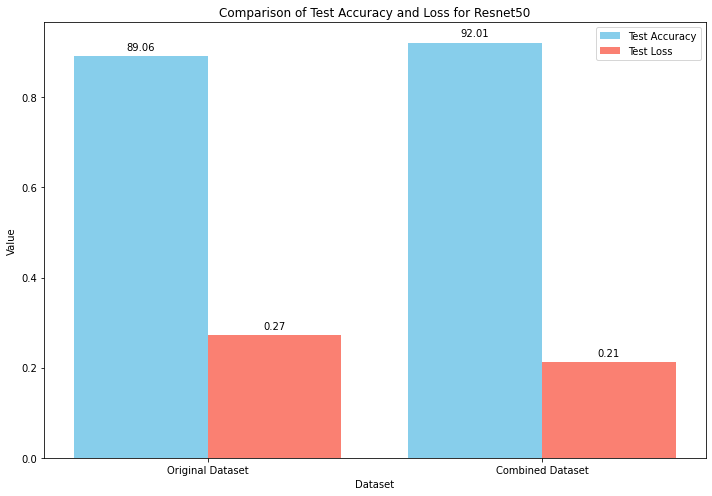

In [14]:
test_acc_values = [test_acc_original, test_acc_combined]
test_loss_values = [test_loss_original, test_loss_combined]

datasets = ['Original Dataset', 'Combined Dataset']

x = np.arange(len(datasets))  
bar_width = 0.4  

fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.bar(x - bar_width/2, test_acc_values, bar_width, label='Test Accuracy', color='skyblue')

bars2 = ax.bar(x + bar_width/2, test_loss_values, bar_width, label='Test Loss', color='salmon')

for bar, value in zip(bars1, test_acc_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.01,  
        f'{value * 100:.2f}',  
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

for bar, value in zip(bars2, test_loss_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.01,  
        f'{value:.2f}',  
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

ax.set_xlabel('Dataset')
ax.set_ylabel('Value')
ax.set_title('Comparison of Test Accuracy and Loss for Resnet50')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()

plt.tight_layout()
plt.show()


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

true_1, preds_1, probs_1 = evaluate_model(custom_model, original_test_loader, "Original", device)
true_2, preds_2, probs_2 = evaluate_model(custom_model, combined_test_loader, "Combined", device)


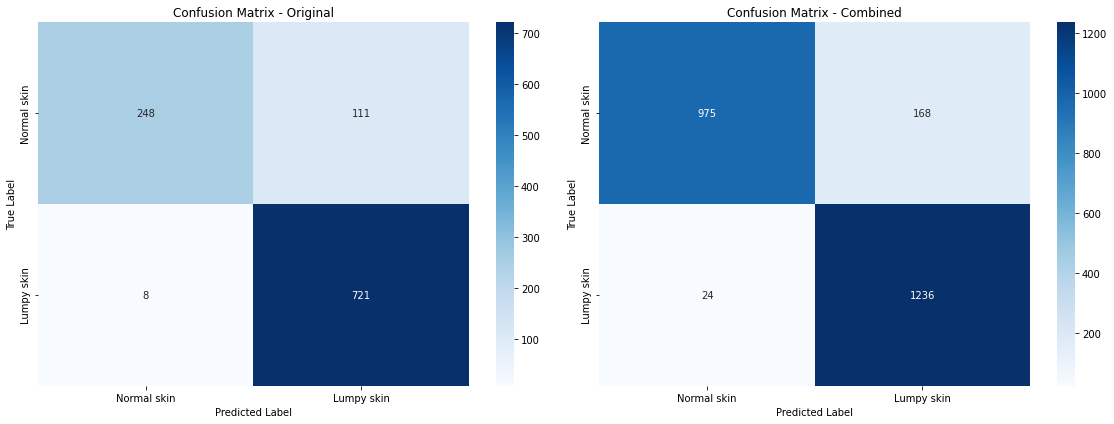

In [16]:

plot_confusion_matrices(true_1, preds_1, "Original", true_2, preds_2, "Combined")


In [17]:

print_metrics(true_1, preds_1, "Original", true_2, preds_2, "Combined")

Metrics for Original Dataset:
              precision    recall  f1-score   support

 Normal skin       0.97      0.69      0.81       359
  Lumpy skin       0.87      0.99      0.92       729

    accuracy                           0.89      1088
   macro avg       0.92      0.84      0.87      1088
weighted avg       0.90      0.89      0.89      1088

Mean Squared Error (MSE): 0.1094
Error Rate: 10.9375%

Metrics for Combined Dataset:
              precision    recall  f1-score   support

 Normal skin       0.98      0.85      0.91      1143
  Lumpy skin       0.88      0.98      0.93      1260

    accuracy                           0.92      2403
   macro avg       0.93      0.92      0.92      2403
weighted avg       0.93      0.92      0.92      2403

Mean Squared Error (MSE): 0.0799
Error Rate: 7.9900%



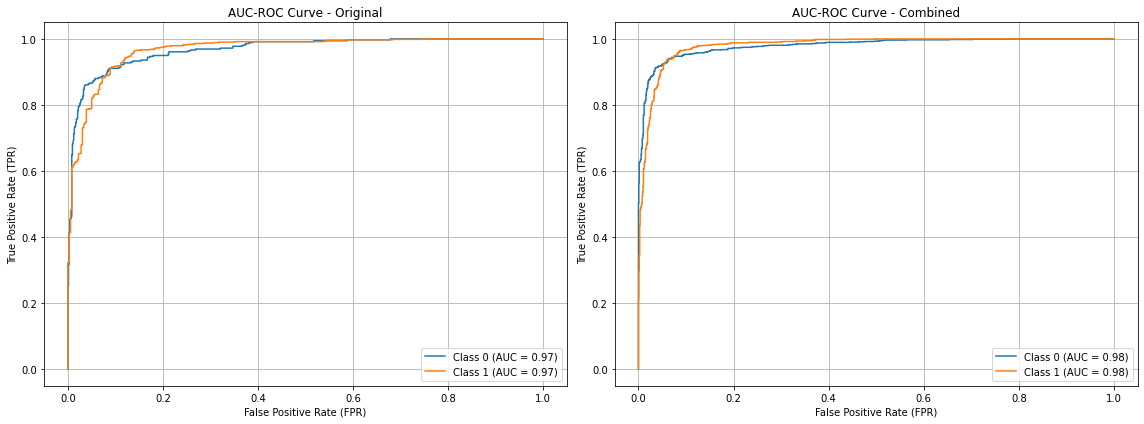

In [18]:

 #plot AUC-ROC Curves
plot_auc_roc(true_1, probs_1, "Original", true_2, probs_2, "Combined")
